In [ ]:
!pip install -q kaggle

In [ ]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Kaggle API Token: ")

Kaggle API Token: ··········


In [ ]:
!kaggle datasets list -s skin

ref                                                                title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                                  Skin Cancer MNIST: HAM10000                     5582914511  2018-09-20 20:36:13.037000         281784       2383  0.7058824        
surajghuwalewala/ham1000-segmentation-and-classification           Skin cancer: HAM10000                           2781385274  2021-05-27 09:08:46.813000          21050        154  0.9411765        
nodoubttome/skin-cancer9-classesisic                               Skin Cancer ISIC                                1647873564  2019-08-26 18:59:21.257000          35889        316  0.75             
pacif

In [ ]:
!kaggle datasets download -d pacificrm/skindiseasedataset

Dataset URL: https://www.kaggle.com/datasets/pacificrm/skindiseasedataset
License(s): CC0-1.0
100% 1.36G/1.36G [00:35<00:00, 41.0MB/s]



In [ ]:
!ls -lh

total 1.4G
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data
-rw-r--r-- 1 root root 1.4G Nov 23  2024 skindiseasedataset.zip


In [ ]:
!unzip -q skindiseasedataset.zip -d /content/SkinDisease

In [ ]:
!find /content/SkinDisease -maxdepth 3 -type d

/content/SkinDisease
/content/SkinDisease/SkinDisease
/content/SkinDisease/SkinDisease/SkinDisease
/content/SkinDisease/SkinDisease/SkinDisease/train
/content/SkinDisease/SkinDisease/SkinDisease/test


In [ ]:
from pathlib import Path

data_path = Path("/content/SkinDisease/SkinDisease/SkinDisease")
image_path = data_path

In [ ]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [ ]:
import os
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

check_data(image_path)

# of directories: 2 and 0 images in '/content/SkinDisease/SkinDisease/SkinDisease'.
# of directories: 22 and 0 images in '/content/SkinDisease/SkinDisease/SkinDisease/train'.
# of directories: 0 and 923 images in '/content/SkinDisease/SkinDisease/SkinDisease/train/Tinea'.
# of directories: 0 and 461 images in '/content/SkinDisease/SkinDisease/SkinDisease/train/Vasculitis'.
# of directories: 0 and 361 images in '/content/SkinDisease/SkinDisease/SkinDisease/train/Moles'.
# of directories: 0 and 504 images in '/content/SkinDisease/SkinDisease/SkinDisease/train/Bullous'.
# of directories: 0 and 455 images in '/content/SkinDisease/SkinDisease/SkinDisease/train/Seborrh_Keratoses'.
# of directories: 0 and 1651 images in '/content/SkinDisease/SkinDisease/SkinDisease/train/Unknown_Normal'.
# of directories: 0 and 1093 images in '/content/SkinDisease/SkinDisease/SkinDisease/train/Benign_tumors'.
# of directories: 0 and 714 images in '/content/SkinDisease/SkinDisease/SkinDisease/train/Vitiligo'.


In [ ]:
train_dir

PosixPath('/content/SkinDisease/SkinDisease/SkinDisease/train')

In [52]:
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

manuel_transforms = transforms.Compose(
    [
        transforms.Resize((224,224)),
        transforms.RandomHorizontalFlip(p=0.5), # Resmi yatay döndür
        transforms.RandomVerticalFlip(p=0.5),   # Resmi dikey döndür
        transforms.RandomRotation(degrees=15),  # Hafif döndürme ekle
        transforms.ColorJitter(brightness=0.2, contrast=0.2), # Işık ayarları
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    ]
)

NUM_WORKERS = os.cpu_count()
#NUM_WORKERS = 0 # you can make this 0 if you get any error on mac silicon

def create_dataloaders(
    train_dir: str,
    test_dir: str,
    transform: transforms.Compose,
    batch_size: int,
    num_workers: int=NUM_WORKERS
):
  # Use ImageFolder to create dataset(s)
  train_data = datasets.ImageFolder(train_dir, transform=transform)
  test_data = datasets.ImageFolder(test_dir, transform=transform)

  # Get class names
  class_names = train_data.classes

  # Turn images into data loaders
  train_dataloader = DataLoader(
      train_data,
      batch_size=batch_size,
      shuffle=True,
      num_workers=num_workers,
      pin_memory=True,
  )
  test_dataloader = DataLoader(
      test_data,
      batch_size=batch_size,
      shuffle=False, # don't need to shuffle test data
      num_workers=num_workers,
      pin_memory=True,
  )

  return train_dataloader, test_dataloader, class_names

train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir=train_dir,test_dir=test_dir,transform=manuel_transforms,batch_size= 32)


In [53]:

train_dataloader

In [54]:
class_names

['Acne',
 'Actinic_Keratosis',
 'Benign_tumors',
 'Bullous',
 'Candidiasis',
 'DrugEruption',
 'Eczema',
 'Infestations_Bites',
 'Lichen',
 'Lupus',
 'Moles',
 'Psoriasis',
 'Rosacea',
 'Seborrh_Keratoses',
 'SkinCancer',
 'Sun_Sunlight_Damage',
 'Tinea',
 'Unknown_Normal',
 'Vascular_Tumors',
 'Vasculitis',
 'Vitiligo',
 'Warts']

In [55]:
import torchvision

weights =torchvision.models.ConvNeXt_Tiny_Weights.DEFAULT


In [56]:
weights

ConvNeXt_Tiny_Weights.IMAGENET1K_V1

In [57]:
auto_transforms = weights.transforms()

train_dataloader, test_dataloader, class_names = create_dataloaders(train_dir=test_dir,test_dir=test_dir,transform=auto_transforms,batch_size= 32)


In [58]:

import torch

torch.cuda.is_available()

device = "cuda" if  torch.cuda.is_available() else "cpu"

In [59]:


device

'cuda'

In [60]:
model = torchvision.models.convnext_tiny(weights=weights).to(device)

In [38]:

import torch
from torchinfo import summary
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# 1. Modeli ve ağırlıkları temiz bir şekilde yükleyin
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

# 2. Önceden eğitilmiş feature katmanlarını dondurun
for param in model.features.parameters():
    param.requires_grad = False

# Sınıf sayınız
output_shape = len(class_names)

# 3. KESİN ÇÖZÜM: Classifier yapısını orijinal katmanlarıyla sıfırdan güvenlice kuralım
# Bu sayede indeks hatası (IndexError) almazsınız ve havuzlama katmanları korunur
model.classifier = torch.nn.Sequential(
    torch.nn.AdaptiveAvgPool2d(output_size=(1, 1)),
    torch.nn.Flatten(start_dim=1, end_dim=-1),
    torch.nn.Linear(in_features=768, out_features=output_shape, bias=True)
)

# 4. Modeli GPU'ya gönderin
model = model.to(device)

# 5. Özeti kontrol edin (Sorunsuz çalışacaktır)
summary(model=model,
        input_size=(32, 3, 224, 224),
        col_names=["output_size", "num_params", "trainable"])

Layer (type:depth-idx)                        Output Shape              Param #                   Trainable
ConvNeXt                                      [32, 22]                  --                        Partial
├─Sequential: 1-1                             [32, 768, 7, 7]           --                        False
│    └─Conv2dNormActivation: 2-1              [32, 96, 56, 56]          --                        False
│    │    └─Conv2d: 3-1                       [32, 96, 56, 56]          (4,704)                   False
│    │    └─LayerNorm2d: 3-2                  [32, 96, 56, 56]          (192)                     False
│    └─Sequential: 2-2                        [32, 96, 56, 56]          --                        False
│    │    └─CNBlock: 3-3                      [32, 96, 56, 56]          (79,296)                  False
│    │    └─CNBlock: 3-4                      [32, 96, 56, 56]          (79,296)                  False
│    │    └─CNBlock: 3-5                      [32, 96, 56,

In [61]:
from torch import nn

loss_fn=nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device): # Added device parameter
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X,y = X.to(device) ,y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [62]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device): # Added device parameter
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):

            X,y = X.to(device),y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

results = train(model = model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                device=device,
                epochs=25)


Epoch: 1 | train_loss: 3.2697 | train_acc: 0.1278 | test_loss: 2.7587 | test_acc: 0.1435
Epoch: 2 | train_loss: 2.7127 | train_acc: 0.1880 | test_loss: 2.7325 | test_acc: 0.1703
Epoch: 3 | train_loss: 2.6244 | train_acc: 0.2023 | test_loss: 2.6555 | test_acc: 0.2175
Epoch: 4 | train_loss: 2.5048 | train_acc: 0.2288 | test_loss: 2.4143 | test_acc: 0.2455
Epoch: 5 | train_loss: 2.3900 | train_acc: 0.2680 | test_loss: 2.3185 | test_acc: 0.2825
Epoch: 6 | train_loss: 2.2626 | train_acc: 0.3056 | test_loss: 2.1294 | test_acc: 0.3471
Epoch: 7 | train_loss: 2.1712 | train_acc: 0.3237 | test_loss: 2.1457 | test_acc: 0.3253
Epoch: 8 | train_loss: 2.1048 | train_acc: 0.3468 | test_loss: 1.8264 | test_acc: 0.4380
Epoch: 9 | train_loss: 1.9552 | train_acc: 0.3796 | test_loss: 1.7427 | test_acc: 0.4434
Epoch: 10 | train_loss: 1.8308 | train_acc: 0.4231 | test_loss: 1.4496 | test_acc: 0.5452
Epoch: 11 | train_loss: 1.6538 | train_acc: 0.4726 | test_loss: 1.4358 | test_acc: 0.5392
Epoch: 12 | train_l

In [63]:
import torch

# Şu an hafızada duran %99.30'luk gerçek şampiyonu kaydediyoruz
torch.save(obj=model.state_dict(), f="convnext_skin_real_success_99.pth")
print("Muhteşem! Gerçek %99 doğruluğa sahip model başarıyla kaydedildi!")



Muhteşem! Gerçek %99 doğruluğa sahip model başarıyla kaydedildi!


In [70]:
from PIL import Image

import matplotlib.pyplot as plt

from typing import List,Tuple

def transform_predict(model : torch.nn.Module,
                      image_path:str,
                      class_names : List[str],
                      image_size : Tuple[int,int] = (224,224),
                      transform :torchvision.transforms =None,
                      device : torch.device = device
                      ):
  img = Image.open(image_path)
  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([ # Changed transform.Compose to transforms.Compose
        transforms.Resize(image_size), # Changed transform.Resize to transforms.Resize
        transforms.ToTensor(), # Changed transform.ToTensor to transforms.ToTensor
        transforms.Normalize(mean=[0.485,0.456,0.406],
                             std = [0.229,0.224,0.225])

    ])


  model.to(device)
  model.eval()
  with torch.inference_mode():
   transformed_image = image_transform(img).unsqueeze(dim=0)
   target_image_pred = model(transformed_image.to(device))

  target_image_pred_probs = torch.softmax(target_image_pred,dim = 1)
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim = 1)
  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {class_names[target_image_pred_label]} , Probs: {target_image_pred_probs.max()}")


In [73]:
custom_image_path = data_path / "/content/test_cilt.jpg"


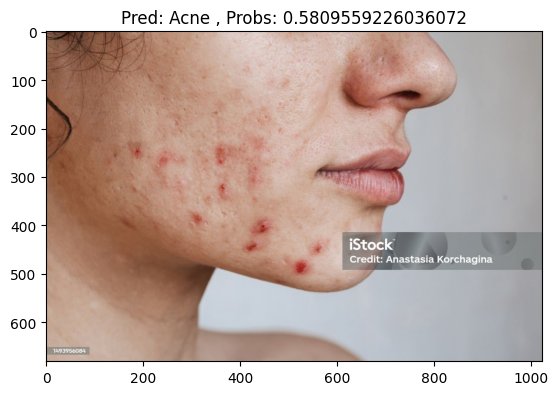

In [74]:
transform_predict(model,custom_image_path,class_names)

In [75]:
custom_image_path1 = data_path / "/content/test-cilt_2.jpg"

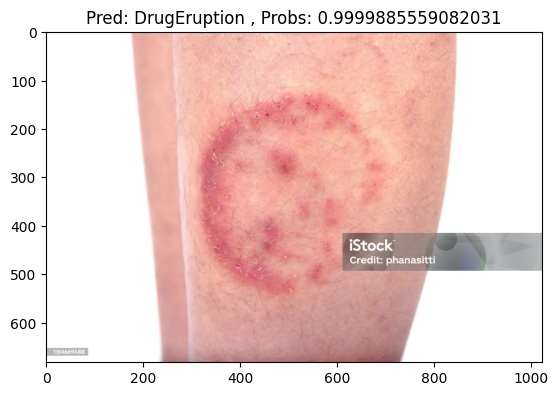

In [76]:
transform_predict(model,custom_image_path1,class_names)

In [79]:
custom_image_path2 = data_path / "/content/ırmak.jpeg"

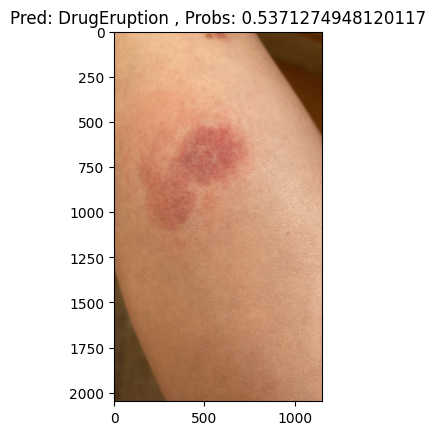

In [80]:
transform_predict(model,custom_image_path2,class_names)

In [81]:
custom_image_path3 = data_path / "/content/osi.jpeg"

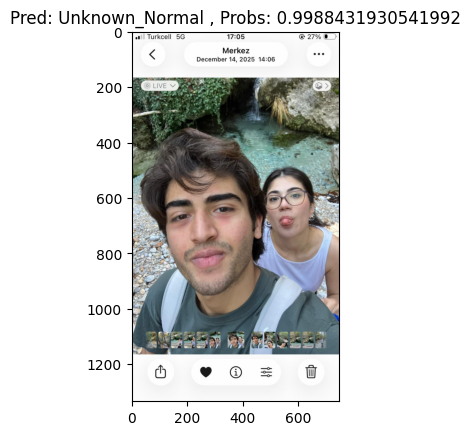

In [82]:
transform_predict(model,custom_image_path3,class_names)

In [87]:
custom_image_path4 = data_path / "/content/converted.jpg"

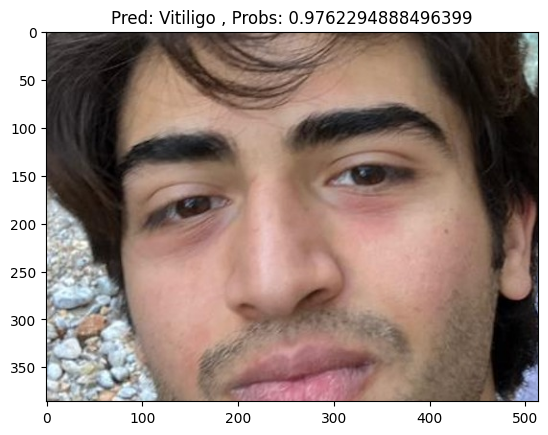

In [88]:
transform_predict(model,custom_image_path4,class_names)

In [89]:
custom_image_path5 = data_path / "/content/ırmak2.jpeg"

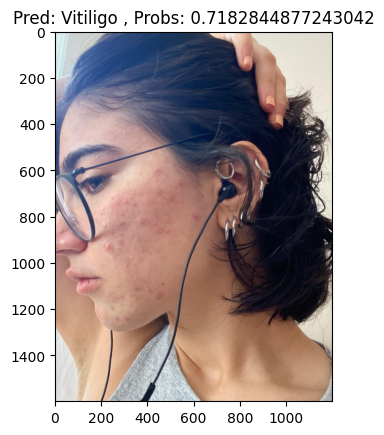

In [90]:
transform_predict(model,custom_image_path5,class_names)

In [94]:
custom_image_path6 = data_path / "/content/157__ProtectWyJQcm90ZWN0Il0_FocusFillWzI5NCwyMjIsIngiLDFd.jpeg"

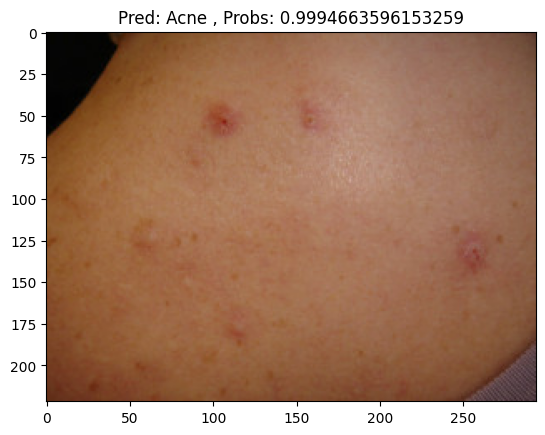

In [95]:
transform_predict(model,custom_image_path6,class_names)

In [97]:
custom_image_path7 = data_path / "/content/rosa.jpg"

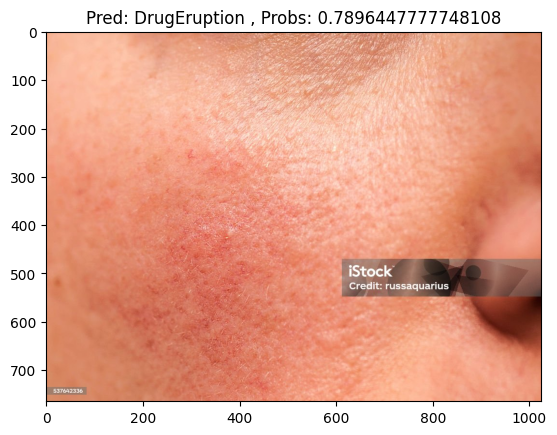

In [98]:
transform_predict(model,custom_image_path7,class_names)